connectivity measruements across patients
DI, probabilities etc

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import pandas as pd

import sys

sys.path.append('T:\EL_experiment\Codes\CCEP_human\Python_Analysis/py_functions')

from scipy.stats import norm
from tkinter import *
import scipy
from scipy import signal

import platform
from glob import glob
from scipy.spatial import distance
import basic_func as bf
from scipy.integrate import simps
from numpy import trapz
import tqdm
from matplotlib.patches import Rectangle
from pathlib import Path
import statsmodels.api as sm
import statsmodels.formula.api as smf

#
from scipy.signal import hilbert, butter, filtfilt
import scipy.stats as stats
from tqdm.notebook import trange, tqdm
import load_summary as ls
cwd             = os.getcwd()
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.colors
import matplotlib 

##all 
cond_vals   = np.arange(4)
cond_labels = ['BM', 'BL', 'Fuma', 'Benzo']
cond_colors = ['#494159','#594157', "#F1BF98","#8FB996"]
dist_groups = np.array([[0,15],[15,30],[30,5000]])
dist_labels = ['local (<15 mm)', 'short (<30mm)', 'long']
sub_path  ='X:\\4 e-Lab\\' # y:\\eLab

sys.path.append('T:\\EL_experiment\Codes\CCEP_human\Python_Analysis\py_functions')
sys.path.append('X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram')
sys.path.append('T:\\EL_experiment\Codes\\UBELIX_EvM\\NMF\\functions')
path_connectogram = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram'
from main_script import ConnectogramPlotter
cwp = os.getcwd()

In [3]:
CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
tab_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='plot')
tab_region = tab_region.sort_values('Order').reset_index(drop=True)
regions_all = tab_region.Area.values
region_col = tab_region.color.values

CIRC_AREAS_FILEPATH = 'X:\\4 e-Lab\e-Lab shared code\Softwares\Connectogram\circ_areas.xlsx'
all_region = pd.read_excel(CIRC_AREAS_FILEPATH, sheet_name='atlas')

In [4]:
plt.rcParams.update({
            'font.family': 'arial',
            'font.size': 12,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'svg.fonttype': 'none',
            'font.size': 10,
            'axes.titlesize': 10,
            'axes.labelsize': 8,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'figure.titlesize': 10
        })

In [5]:
color_elab = np.zeros((3, 3))
color_elab[0, :] = np.array([31, 78, 121]) / 255
color_elab[1, :] = np.array([189, 215, 238]) / 255
color_elab[2, :] = np.array([0.256, 0.574, 0.431])
DI_color = 'PRGn'

In [6]:
 color_d, color_dist, color_group, color_elab = ls.get_color()

In [7]:

#import BM_across_plots as plotting

cwd = os.getcwd()

##all
cond_vals = np.arange(4)
cond_labels = ['BM', 'BL', 'Fuma', 'Benzo']
cond_colors = ['#494159', '#594157', "#F1BF98", "#8FB996"]
dist_groups = np.array([[0, 15], [15, 30], [30, 5000]])
dist_labels = ['local (<15 mm)', 'short (<30mm)', 'long']
sub_path = 'X:\\4 e-Lab\\'  # y:\\eLab

##
subjs = ["EL010", "EL011", "EL012", "EL013", "EL014", "EL015", "EL016", "EL019", "EL020", "EL021",
         "EL022", "EL024", "EL026", "EL027", "EL028"]


In [8]:

df_nodes =  ls.get_nodes(subjs, sub_path, metric ='unweighted')

In [9]:
df_plot = df_nodes[df_nodes.SleepState=='Wake'].reset_index(drop=True)

In [10]:
for subj in subjs:
    n_chan = len(np.unique(df_plot.loc[(df_plot.Subj == subj),'Chan']))
    # normlize by number of channels
    df_plot.loc[(df_plot.Subj == subj), 'Dout_norm'] = df_plot.loc[(df_plot.Subj == subj), 'Dout'] / n_chan
    df_plot.loc[(df_plot.Subj == subj), 'Din_norm'] = df_plot.loc[(df_plot.Subj == subj), 'Din'] / n_chan
    # normalize z-score 
    df_plot.loc[(df_plot.Subj == subj), 'Cb_zscore'] = (df_plot.loc[(df_plot.Subj == subj), 'Cb'] -np.mean(df_plot.loc[(df_plot.Subj == subj), 'Cb']))/ np.std(df_plot.loc[(df_plot.Subj == subj), 'Cb'])
    df_plot.loc[(df_plot.Subj == subj), 'Cc_zscore'] = (df_plot.loc[(df_plot.Subj == subj), 'Cc'] -np.mean(df_plot.loc[(df_plot.Subj == subj), 'Cc']))/ np.std(df_plot.loc[(df_plot.Subj == subj), 'Cc'])
                                                    


In [11]:
df_plot.loc[df_plot.Din<df_plot.Dout, 'D_R'] = 1-(df_plot['Din']/df_plot['Dout'])
df_plot.loc[df_plot.Din>df_plot.Dout, 'D_R'] = (df_plot['Dout']/df_plot['Din'])-1

# NODE - LEVEL

In [12]:
epi_color = ['#5b388d', '#cdb0e8', '#ffc8b9']

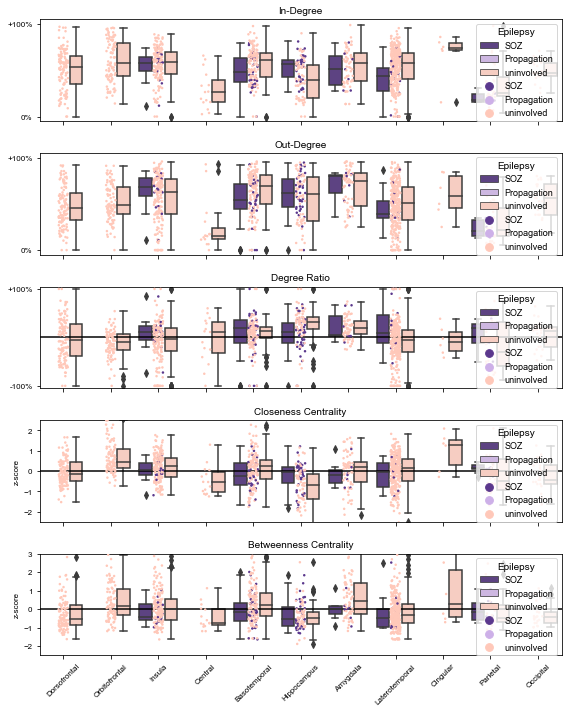

In [13]:
# Combine all metrics and labels into a single list for easier management
metrics = ['Din_norm', 'Dout_norm', 'D_R', 'Cc_zscore', 'Cb_zscore']
metric_labels = [ 'In-Degree', 'Out-Degree', 'Degree Ratio','Closeness Centrality', 'Betweenness Centrality']
ylim_values = [(-0.05, 1.05), (-0.05, 1.05),(-1.05, 1.05),  (-2.5, 2.5), (-2.5, 3)]
ytick_values = [([0, 1], ['0%', '+100%']), 
                ([0, 1], ['0%', '+100%']), ([-1, 1], ['-100%', '+100%']), (None, None), (None, None)]
y_labels = [ None, None, None,'z-score', 'z-score']
# Create subplots
fig, axes = plt.subplots(len(metrics), 1, figsize=(8, 10), sharex=True)
fig.patch.set_facecolor('xkcd:white')
hue ='Epilepsy'
# Loop over each metric and plot in the respective subplot
for idx, (metric, label, ylim, yticks, yl) in enumerate(zip(metrics, metric_labels, ylim_values, ytick_values,y_labels)):
    ax = axes[idx]
    sns.boxplot(x='ChanR', y=metric, data=df_plot, order=regions_all,hue = hue,hue_order = ['SOZ', 'Propagation', 'uninvolved'], palette = epi_color, ax=ax)
    sns.stripplot(x='ChanR', y=metric, data=df_plot, order=regions_all,hue = hue,hue_order = ['SOZ', 'Propagation', 'uninvolved'], palette = epi_color, ax=ax, s = 2.5)
    
    #sns.stripplot(x='ChanR', y=metric, data=df_plot, order=regions_all, alpha=0.5, color='k', s=2, ax=ax)
    ax.set_ylim(ylim)
    ax.set_title(label)
    
   
    if ylim[0]<-0.5:
        ax.axhline(0, color='k')
    if yticks[0] is not None:
        ax.set_yticks(yticks[0])
        ax.set_yticklabels(yticks[1])
    
    # Only set xticks and labels on the last subplot
    if idx == len(metrics) - 1:
        ax.set_xticklabels(regions_all, rotation=45)
    else:
        ax.set_xticklabels([])

    ax.set_ylabel(yl)
    ax.set_xlabel('')

# Show the figure
plt.tight_layout()
file = os.path.join(sub_path,'EvM\Projects\EL_experiment\Analysis\Supp_figures', 'Nodes', 'graph_metrics_regions_'+hue+'.svg')
plt.savefig(file)

# Connections

In [143]:
con_all = ls.get_connections(subjs, sub_path)
con_all_ss = ls.get_connections_sleep(subjs, sub_path, ['Wake'])

In [144]:
con_all['Con_ID'] = con_all.groupby(['Subj', 'Stim', 'Chan']).ngroup()
con_all.insert(6, 'Group', 'indirect')
con_all.loc[(con_all.d < 20) & (con_all.delay < 0.02), 'Group'] = 'local direct'
con_all.loc[(con_all.d > 20) & (con_all.delay < 0.02), 'Group'] = 'long direct'

In [145]:
con_all_DI = con_all[~np.isnan(con_all.DI)].reset_index(drop=True)

In [146]:
con_all_sel = con_all[(con_all.Zscore>3)&(con_all.Num_sig_trial >10)&(con_all.True_peak == 1)].reset_index(drop=True)
# con_all_sel = con_all[~np.isnan(con_all.DI)].reset_index(drop=True)
data_sel = con_all_ss.merge(con_all_sel[['Subj', 'Stim', 'Chan', 'Con_ID', 'Group']], on=['Subj', 'Stim', 'Chan'])

## CCEP Probability & DI by distance

In [183]:
data_sel['DI_abs'] = abs(data_sel.DI)

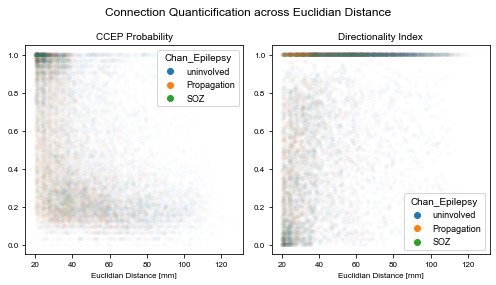

In [184]:
data_sel['DI_abs'] = abs(data_sel.DI)
y_metric_all = ['Sig', 'DI_abs', 'Mean_LL', 'Mean_P2P']
y_metric_all = ['CCEP Probability', 'Directionality Index', 'LL of mean signal', 'P2P of mean signal']
fig, axs = plt.subplots(1, 2, figsize=(7,4))  # Creates a 2x2 grid of subplots
axs = axs.flatten()  # Flattens the 2D array of axes for easy iteration

for i, (y_value, y_title) in enumerate(zip(['Sig', 'DI_abs'], ['CCEP Probability', 'Directionality Index'])):
    sns.scatterplot(x='d', y=y_value, data=data_sel, hue='Chan_Epilepsy', alpha=0.01, s=20, ax=axs[i])
    axs[i].set_title(y_title, fontsize = 10)
    
    if y_value == 'Mean_LL':
        axs[i].set_ylabel('$\\mu V/ms$', fontsize = 8)  # Using LaTeX formatting for mu
    elif y_value == 'Mean_P2P':
        axs[i].set_ylabel('$\\Delta V$', fontsize = 8)  # Using LaTeX formatting for delta
    else:
        axs[i].set_ylabel('')

    axs[i].set_xlabel('Euclidian Distance [mm]', fontsize = 8)
plt.suptitle('Connection Quanticification across Euclidian Distance', fontsize = 12)
plt.tight_layout()
filename = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\Flow\\P_DI_distance_Epi'
file = filename+'.png'
fig.savefig(file,dpi = 300, format='png')
plt.show()

## DI, P scatter

In [185]:
df = con_all_ss.copy()
all_pairs = pd.concat([df[['Subj', 'Stim', 'Chan', 'Sig','d']],
                       df.rename(columns={'Stim': 'Chan', 'Chan': 'Stim'})[['Subj', 'Chan', 'Stim', 'Sig','d']]]).reset_index(
    drop=True)
grouped = all_pairs.groupby(['Subj','Stim', 'Chan','d'], as_index=False)['Sig'].agg(['max', 'min', 'sum']).reset_index()
all_pairs = all_pairs.merge(grouped, on=['Subj','Stim', 'Chan'])
all_pairs['is_min'] = (all_pairs['Sig'] == all_pairs['min']) & (all_pairs['Sig'] != all_pairs['max'])
all_pairs['DI'] = np.where((all_pairs['min'] == 0) & (all_pairs['max'] == 0), np.nan,
                                   np.where(all_pairs['min'] == all_pairs['max'], 0,
                                            (1 - all_pairs['min'] / all_pairs['max']) * all_pairs['is_min'].map(
                                                {True: -1, False: 1})))
all_pairs = all_pairs[(all_pairs['sum'] > all_pairs.Sig)]
all_pairs = all_pairs[~np.isnan(all_pairs.DI)].reset_index(drop=True)
all_pairs['Sig_2'] = np.where((all_pairs['min'] == all_pairs['Sig'] ), all_pairs['max'],all_pairs['min'])
all_pairs.loc[all_pairs.Sig<=0, 'Sig'] = -0.1 +np.random.random(len(all_pairs.loc[all_pairs.Sig<=0, 'Sig'] ))/20

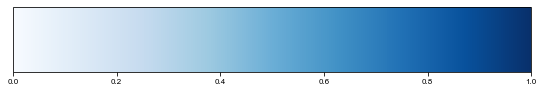

In [150]:
a = np.array([[0,1]])
plt.figure(figsize=(9, 1.5))
img = plt.imshow(a, cmap="Blues")
plt.gca().set_visible(False)
cax = plt.axes([0.1, 0.2, 0.8, 0.6])
plt.colorbar(orientation="horizontal", cax=cax)

In [151]:
c_P = color_elab[0]
c_DI = color_elab[2]

### Brain regions

In [191]:
con_all = ls.get_connections(subjs, sub_path)
con_all_ss = ls.get_connections_sleep(subjs, sub_path, ['Wake'])

In [193]:
con_all['Con_ID'] = con_all.groupby(['Subj', 'Stim', 'Chan']).ngroup()
con_all.insert(6, 'Group', 'indirect')
con_all.loc[(con_all.d < 20) & (con_all.delay < 0.02), 'Group'] = 'local direct'
con_all.loc[(con_all.d > 20) & (con_all.delay < 0.02), 'Group'] = 'long direct'

In [194]:
con_all_sel = con_all[(con_all.Zscore>3)&(con_all.Num_sig_trial >10)&(con_all.True_peak == 1)].reset_index(drop=True)
#con_all_sel = con_all[(con_all.d>20)].reset_index(drop=True)
data_sel = con_all_ss.merge(con_all_sel[['Subj', 'Stim', 'Chan', 'Con_ID', 'Group']], on=['Subj', 'Stim', 'Chan'])

In [157]:
# data_sel.loc[(data_sel.Stim_Epilepsy) == 'Propagation', 'Stim_Epilepsy'] = 'SOZ'
# data_sel.loc[(data_sel.Chan_Epilepsy) == 'Propagation', 'Chan_Epilepsy'] = 'SOZ'

In [158]:
SOZ_labels = ['SOZ', 'Propagation','uninvolved']


Text(54.640625, 0.5, 'Stimulation Region')

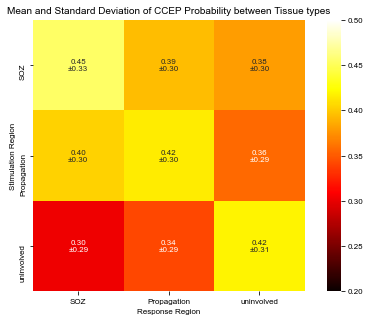

In [200]:
group_columns =   ['Stim_Epilepsy', 'Chan_Epilepsy']# ['StimR', 'ChanR']
group_labels = SOZ_labels #regions_all # 'SOZ','uninvolved'] #
h = 0
metric = 'Sig'

cal = 'median'
if metric == 'DI':
    metric_label = 'Directionality Index'
    cmap_metric = 'PRGn'
    vmin = -1
    con_all_sel = con_all[(con_all.d>20)].reset_index(drop=True)
    data_sel = con_all_ss.merge(con_all_sel[['Subj', 'Stim', 'Chan', 'Con_ID', 'Group']], on=['Subj', 'Stim', 'Chan'])

else:
    # metric = 'Sig'
    metric_label = 'CCEP Probability'
    cmap_metric = 'RdGy_r'
    vmin = 0
    # Define color values and corresponding colors
    cvals  = [0, 0.1, 0.2, 0.5]
    colors = ["black","black", "firebrick", "orange"]

    # Normalize the color values to be between 0 and 1
    norm = matplotlib.colors.Normalize(min(cvals), max(cvals))
    norm_cvals = [norm(val) for val in cvals]

    # Create tuples of normalized values and colors
    tuples = list(zip(norm_cvals, colors))

    # Create the colormap
    cmap_metric = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)
    cmap_metric = 'hot'

    con_all_sel = con_all[(con_all.Sig>0.005)&(con_all.d>20)].reset_index(drop=True)
    data_sel = con_all_ss.merge(con_all_sel[['Subj', 'Stim', 'Chan', 'Con_ID', 'Group']], on=['Subj', 'Stim', 'Chan'])


data_Con_prob = data_sel[['Subj','Con_ID', group_columns[0], group_columns[1], 'DI', 'Sig', 'd', 'H']].reset_index(drop=True)
data_Con_prob = data_Con_prob[(np.isin(data_Con_prob[group_columns[0]], group_labels)) & (np.isin(data_Con_prob[group_columns[1]], group_labels))].reset_index(drop=True)
data_Con_prob = data_Con_prob[~np.isnan(data_Con_prob[metric])]
grouped_data = data_Con_prob.groupby(group_columns)[metric].agg([cal, 'std'])

# 2. Create a Data Matrix
data_matrix = pd.DataFrame(index=group_labels, columns=group_labels)
for (stim, chan), values in grouped_data.iterrows():
    if stim in group_labels and chan in group_labels:
        data_matrix.at[stim, chan] = f"{values[cal]:.2f}\n±{values['std']:.2f}"

# Reorder data matrix and annotation matrix
reordered_data = grouped_data[cal].unstack().reindex(index=group_labels, columns=group_labels)
annot_matrix = data_matrix.reindex(index=group_labels, columns=group_labels)

# 3. Plot the Heatmap with ordered x-ticks and colorbar limit
fig = plt.figure(figsize=(8, 5))
fig.patch.set_facecolor('xkcd:white')
ax = sns.heatmap(reordered_data, annot=annot_matrix,annot_kws={"fontsize":8}, fmt='', cmap=cmap_metric, cbar=True, vmin =0.2, vmax=0.5)

# Ensuring the heatmap is square
ax.set_aspect('equal', 'box')
# 4. Add titles and labels
plt.title('Mean and Standard Deviation of ' +metric_label +' between Tissue types')
file = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\Flow\\'+metric+'_EpiTissue_interH.svg'

plt.xlabel('Response Region')
plt.ylabel('Stimulation Region')
# plt.savefig(file)

# Connection Probability

In [203]:
factor = 2
plt.rcParams.update({
            'font.family': 'arial',
            'font.size': 12*factor,
            'xtick.labelsize': 8*factor,
            'ytick.labelsize': 8*factor,
            'legend.fontsize': 9*factor,
            'svg.fonttype': 'none',
            'font.size': 10*factor,
            'axes.titlesize': 10*factor,
            'axes.labelsize': 8*factor,
            'xtick.labelsize': 8*factor,
            'ytick.labelsize': 8*factor,
            'legend.fontsize': 9*factor,
            'figure.titlesize': 10*factor
        })

In [163]:
subjs = ["EL010", "EL011", "EL012", "EL013", "EL014", "EL015", "EL016", "EL019", "EL020", "EL021",
         "EL022", "EL024", "EL026", "EL027", "EL028"]

In [201]:
import load_summary as ls
con_all = ls.get_connections(subjs, sub_path)
# con_all = con_all[(con_all.Num_sig_trial >10)&(con_all.True_peak == 1)].reset_index(drop=True)
con_all['Con_ID'] = con_all.groupby(['Subj', 'Stim', 'Chan']).ngroup()
con_all['Sig_Con'] = 0
con_all.loc[(con_all.Sig>0)&(con_all.True_peak==1), 'Sig_Con'] = 1
con_all = con_all[con_all.H==0].reset_index(drop=True)

In [202]:
data_Con_prob = con_all[['Con_ID', 'Stim_Epilepsy', 'Chan_Epilepsy', 'Sig_Con', 'd']].reset_index(drop=True)
# data_Con_prob = data_Con_prob[(np.isin(data_Con_prob.StimR, regions_all))&(np.isin(data_Con_prob.ChanR, regions_all))].reset_index(drop=True)

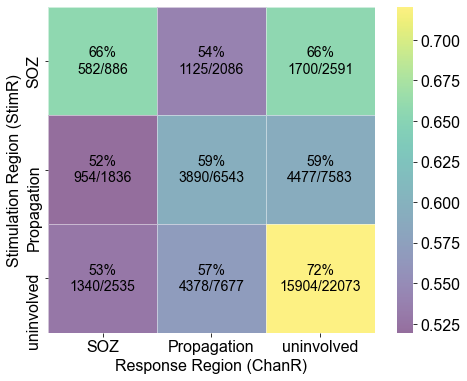

In [206]:
# Calculate the ratio of Sig_Con == 1 to the total number of connections for each pair of regions
heatmap_data = data_Con_prob.groupby(['Stim_Epilepsy', 'Chan_Epilepsy'])['Sig_Con'].mean().unstack(fill_value=np.nan)

# Create a DataFrame with NaN values for missing labels
missing_labels = list(set(SOZ_labels) - set(heatmap_data.index))
for lab in missing_labels:
    empty_array = pd.DataFrame([[np.max(data_Con_prob.Con_ID)+1, lab, lab, np.nan, np.nan, h]], columns=['Con_ID', 'StimR', 'ChanR', 'Sig_Con', 'd', 'H'])
    data_Con_prob = pd.concat([data_Con_prob, empty_array], 0)
data_Con_prob = data_Con_prob.reset_index(drop=True)

heatmap_data = data_Con_prob.groupby(['Stim_Epilepsy', 'Chan_Epilepsy'])['Sig_Con'].mean().unstack(fill_value=np.nan)
heatmap_data = heatmap_data.loc[SOZ_labels, SOZ_labels]  # Reorder rows and columns

# Create the heatmap
fig = plt.figure(figsize=(4*factor, 3*factor))
fig.patch.set_facecolor('xkcd:white')
ax = sns.heatmap(heatmap_data, annot=False, cmap='viridis', alpha=0.57, fmt='.2f', linewidths=0.5, xticklabels=SOZ_labels, yticklabels=SOZ_labels)

plt.xlabel('Response Region (ChanR)')
plt.ylabel('Stimulation Region (StimR)')

# Annotate the heatmap with count values (percentage and actual ratio)
for i in range(len(SOZ_labels)):
    for j in range(len(SOZ_labels)):
        count_all = len(data_Con_prob[(data_Con_prob.Sig_Con>=0)&(data_Con_prob.Stim_Epilepsy==SOZ_labels[i])&(data_Con_prob.Chan_Epilepsy==SOZ_labels[j])])
        if count_all>0:
            count = len(data_Con_prob[(data_Con_prob.Sig_Con==1)&(data_Con_prob.Stim_Epilepsy==SOZ_labels[i])&(data_Con_prob.Chan_Epilepsy==SOZ_labels[j])])

            ratio = count/count_all
            plt.text(j + 0.5, i + 0.5, f'{ratio*100:.0f}%\n{count}/{count_all}', ha='center', va='center', fontsize=7*factor)
ax.set_aspect('equal')